# Torch Batteries Example: CartPole Reinforcement Learning

This notebook trains a compact Deep Q-Network (DQN) from replay transitions collected in Gymnasium's `CartPole-v1` environment. The example treats temporal-difference learning as an ordinary supervised optimization problem, allowing torch-batteries to manage the training loop while the model owns reinforcement-learning behavior.

## What this notebook demonstrates

- event-driven DQN training and validation
- a model method charged to `AFTER_OPTIMIZER_STEP`
- incremental full-phase metrics with `StatefulMetric`
- value-based `GradientClip`
- epoch-based `LearningRateScheduler`
- structured, lazy inference with `predict_iter()`

[Events reference](https://michalszc.github.io/torch-batteries/reference/events/) · [Metrics guide](https://michalszc.github.io/torch-batteries/guides/metrics/) · [Prediction guide](https://michalszc.github.io/torch-batteries/guides/prediction/)

## 0. Prerequisites

Use Python 3.12 or newer. The next cell installs torch-batteries and the `example`
dependencies into the active notebook environment. Restart the kernel if the
notebook application asks you to do so after installation.

Gymnasium constructs CartPole locally, so no dataset or credentials are required.
The replay collection and training loop are CPU-compatible, although execution time
depends on the machine and the collected episode lengths.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup and reproducibility

CartPole observations contain cart position, cart velocity, pole angle, and pole angular velocity. The agent chooses whether to push left or right. We seed Python, PyTorch, the environment, and its action space so replay collection is reproducible.

In [2]:
import copy
import random
from io import BytesIO

import gymnasium as gym
import matplotlib.pyplot as plt
import torch
from IPython import display as ipython_display
from PIL import Image as PILImage
from torch import nn
from torch.nn import functional as nn_functional
from torch.utils.data import DataLoader, TensorDataset, random_split

import torch_batteries
from torch_batteries import (
    Battery,
    Event,
    EventContext,
    StatefulMetric,
    StepOutput,
    charge,
)

SEED = 42
BATCH_SIZE = 128
COLLECTION_EPISODES = 400
TRAINING_EPOCHS = 12
DISCOUNT = 0.99
TARGET_UPDATE_STEPS = 200

random.seed(SEED)
torch.manual_seed(SEED)

probe_environment = gym.make("CartPole-v1")
observation, _ = probe_environment.reset(seed=SEED)
probe_environment.action_space.seed(SEED)
print(f"torch-batteries: {torch_batteries.__version__}")
print(f"Observation shape: {observation.shape}")
print(f"Available actions: {probe_environment.action_space.n}")
probe_environment.close()

torch-batteries: 0.10.0
Observation shape: (4,)
Available actions: 2


## 2. Collect a replay dataset

A random policy provides varied transitions `(state, action, reward, next_state, done)`. Everything needed by the notebook is created in code; Gymnasium constructs the environment locally. We split the collected transitions into training and validation datasets.

In [2]:
def collect_replay(episodes):
    environment = gym.make("CartPole-v1")
    states, actions, rewards, next_states, dones = [], [], [], [], []
    episode_lengths = []
    for episode in range(episodes):
        state, _ = environment.reset(seed=SEED + episode)
        environment.action_space.seed(SEED + episode)
        length = 0
        while True:
            action = environment.action_space.sample()
            next_state, reward, terminated, truncated, _ = environment.step(action)
            done = terminated or truncated
            states.append(torch.tensor(state, dtype=torch.float32))
            actions.append(action)
            rewards.append(reward)
            next_states.append(torch.tensor(next_state, dtype=torch.float32))
            dones.append(done)
            state = next_state
            length += 1
            if done:
                break
        episode_lengths.append(length)
    environment.close()
    dataset = TensorDataset(
        torch.stack(states),
        torch.tensor(actions, dtype=torch.long),
        torch.tensor(rewards, dtype=torch.float32),
        torch.stack(next_states),
        torch.tensor(dones, dtype=torch.float32),
    )
    return dataset, episode_lengths


replay_dataset, collection_lengths = collect_replay(COLLECTION_EPISODES)
train_size = int(0.8 * len(replay_dataset))
validation_size = len(replay_dataset) - train_size
train_dataset, validation_dataset = random_split(
    replay_dataset,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

print(f"Collected transitions: {len(replay_dataset)}")
mean_collection_length = sum(collection_lengths) / len(collection_lengths)
print(f"Mean random-policy episode length: {mean_collection_length:.1f}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")

Collected transitions: 9056
Mean random-policy episode length: 22.6
Training batches: 57
Validation batches: 15


## 3. Define the DQN and optimization event

The online network learns action values while a frozen target network supplies stable Bellman targets. `TRAIN_STEP` and `VALIDATION_STEP` return `StepOutput`, exposing predicted and target values to Battery metrics.

The model's `update_target_network` method is charged to `AFTER_OPTIMIZER_STEP`. Broadcast handlers run on the model before callbacks, so the target update happens before any callback using the same event. The context's `optimizer_step_idx` counts completed optimizer operations.

Battery's default `OptimizationStep` zeros gradients and performs backward and optimizer operations for every batch. A model or callback can instead provide `CONFIGURE_TRAIN_STEP` when custom accumulation boundaries are needed; only one provider is allowed.

In [3]:
class CartPoleDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.online = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )
        self.target = copy.deepcopy(self.online)
        self.target.requires_grad_(requires_grad=False)
        self.target_updates = 0

    def bellman_step(self, context):
        states, actions, rewards, next_states, dones = context["batch"]
        predicted_values = (
            self.online(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        )
        with torch.no_grad():
            next_values = self.target(next_states).max(dim=1).values
            target_values = rewards + DISCOUNT * (1 - dones) * next_values
        loss = nn_functional.smooth_l1_loss(predicted_values, target_values)
        return StepOutput(
            loss=loss, predictions=predicted_values, targets=target_values
        )

    @charge(Event.TRAIN_STEP)
    def training_step(self, context: EventContext):
        return self.bellman_step(context)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        return self.bellman_step(context)

    @charge(Event.AFTER_OPTIMIZER_STEP)
    def update_target_network(self, context: EventContext):
        if context["optimizer_step_idx"] % TARGET_UPDATE_STEPS == 0:
            self.target.load_state_dict(self.online.state_dict())
            self.target_updates += 1

    @charge(Event.PREDICT_STEP)
    def predict_step(self, context: EventContext):
        (states,) = context["batch"]
        q_values = self.online(states)
        return {"q_values": q_values, "actions": q_values.argmax(dim=1)}

## 4. Add an incremental metric

`BellmanMeanAbsoluteError` implements `StatefulMetric` by retaining only a running absolute-error sum and sample count. Battery resets it before each phase, updates it for every batch, and computes it once after the complete phase. Unlike `CollectedMetric`, memory use does not grow with the number of transitions.

In [4]:
class BellmanMeanAbsoluteError(StatefulMetric):
    def __init__(self):
        self.reset()

    def reset(self):
        self.absolute_error = 0.0
        self.samples = 0

    def update(self, predictions, targets):
        self.absolute_error += (predictions - targets).abs().sum().item()
        self.samples += predictions.numel()

    def compute(self):
        return self.absolute_error / self.samples


bellman_mae = BellmanMeanAbsoluteError()

## 5. Configure callbacks and train

`GradientClip(algorithm="value")` independently clamps every gradient element to `[-0.5, 0.5]`. Norm clipping would instead rescale all gradients together only when their combined norm exceeds the threshold.

`LearningRateScheduler(interval="epoch")` advances `StepLR` after each completed training epoch. With `interval="step"`, it would advance after successful optimizer operations instead.

Bellman targets remain fixed between target-network updates, so loss should generally fall within those intervals. Synchronizing the target network deliberately changes the regression target and can produce a temporary jump. Dashed lines on the plot identify those updates.

Epoch 12/12 [Validation]: 100%|██████████| 15/15 [00:00<00:00, 279.39it/s, Loss=0.0757]


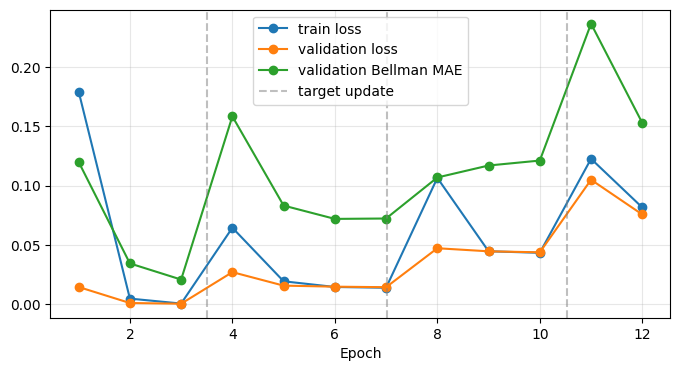

Final learning rate: 0.000125
Target-network updates: 3


In [5]:
from torch_batteries.callbacks import GradientClip, LearningRateScheduler

model = CartPoleDQN()
optimizer = torch.optim.AdamW(model.online.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
callbacks = [
    GradientClip(value=0.5, algorithm="value"),
    LearningRateScheduler(scheduler, interval="epoch"),
]
battery = Battery(
    model,
    optimizer=optimizer,
    metrics={"bellman_mae": bellman_mae},
    callbacks=callbacks,
)
history = battery.train(
    train_loader, validation_loader, epochs=TRAINING_EPOCHS, verbose=1
)

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="validation loss")
plt.plot(
    epochs,
    history["val_metrics"]["bellman_mae"],
    marker="o",
    label="validation Bellman MAE",
)
target_update_epochs = range(
    TARGET_UPDATE_STEPS,
    len(train_loader) * TRAINING_EPOCHS + 1,
    TARGET_UPDATE_STEPS,
)
for index, update_step in enumerate(target_update_epochs):
    plt.axvline(
        update_step / len(train_loader),
        color="gray",
        linestyle="--",
        alpha=0.5,
        label="target update" if index == 0 else None,
    )
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Final learning rate: {optimizer.param_groups[0]['lr']:.6f}")
print(f"Target-network updates: {model.target_updates}")

## 6. Stream Q-value predictions

`predict_iter()` produces one structured dictionary per batch without retaining the complete replay dataset. `move_to_cpu=True` recursively detaches both Q-values and actions before yielding them. Regular `predict(..., concatenate=True)` is appropriate when the complete structured result is small enough to retain.

In [6]:
prediction_states = replay_dataset.tensors[0][:256]
prediction_loader = DataLoader(TensorDataset(prediction_states), batch_size=64)
prediction_batches = list(
    battery.predict_iter(prediction_loader, verbose=1, move_to_cpu=True)
)
predicted_actions = torch.cat([batch["actions"] for batch in prediction_batches])
print(f"Streamed prediction batches: {len(prediction_batches)}")
action_counts = torch.bincount(predicted_actions, minlength=2).tolist()
print(f"Predicted action counts: {action_counts}")

Epoch 1/1 [Predict]: 100%|██████████| 4/4 [00:00<00:00, 391.73it/s]

Streamed prediction batches: 4
Predicted action counts: [153, 103]


## 7. Evaluate the greedy policy

Finally, we run the learned greedy policy in fresh CartPole episodes. The return chart measures performance across several seeds, while an animated recording of the best evaluation episode makes the learned behavior directly visible. The GIF is assembled in memory, so running the notebook does not leave a generated file behind.

This offline example is intentionally simple: performance depends on the coverage of random replay data, while production DQN agents normally collect new transitions as their policy improves.

Mean greedy-policy return: 109.2
Animated episode return: 200


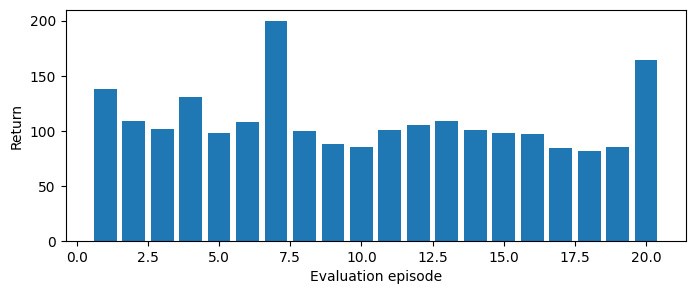

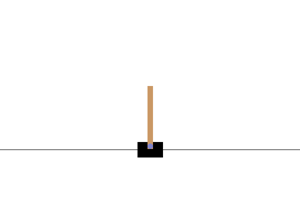

In [7]:
def evaluate_policy(network, episodes=20):
    environment = gym.make("CartPole-v1", render_mode="rgb_array")
    returns = []
    best_frames = []
    best_return = float("-inf")
    network.eval()
    for episode in range(episodes):
        state, _ = environment.reset(seed=SEED + 10_000 + episode)
        total_reward = 0.0
        episode_frames = [environment.render()]
        while True:
            state_tensor = torch.tensor(
                state, dtype=torch.float32, device=battery.device
            )
            with torch.no_grad():
                action = int(network(state_tensor.unsqueeze(0)).argmax(dim=1).item())
            state, reward, terminated, truncated, _ = environment.step(action)
            total_reward += reward
            episode_frames.append(environment.render())
            if terminated or truncated:
                break
        returns.append(total_reward)
        if total_reward > best_return:
            best_return = total_reward
            best_frames = episode_frames
    environment.close()
    return returns, best_frames


def display_episode(frames):
    images = [PILImage.fromarray(frame).resize((300, 200)) for frame in frames[::2]]
    animation = BytesIO()
    images[0].save(
        animation,
        format="GIF",
        save_all=True,
        append_images=images[1:],
        duration=40,
        loop=0,
    )
    ipython_display.display(ipython_display.Image(data=animation.getvalue()))


evaluation_returns, best_episode_frames = evaluate_policy(model.online)
mean_evaluation_return = sum(evaluation_returns) / len(evaluation_returns)
print(f"Mean greedy-policy return: {mean_evaluation_return:.1f}")
print(f"Animated episode return: {max(evaluation_returns):.0f}")
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(evaluation_returns) + 1), evaluation_returns)
plt.xlabel("Evaluation episode")
plt.ylabel("Return")
plt.show()
display_episode(best_episode_frames)